### Vizualization of purely Data Driven approach to measuring exploration

"Whether a model has explored can be measured by the surrpise of the rollouts of the trained model under the base model".

Setup: I've collected validation rollouts during training. For GRPO and Kl-cov, for every checkpoint present in their respective checkpoint directories,
I calculated the logprobs for these validation rollouts. 


In [15]:
import pandas as pd
import os
import numpy as np

In [3]:
paths = [
    '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__grpo/val_jsonl',
    "/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__kl-cov/val_jsonl"
]

In [43]:
def gather_logprobs(path : str):
    checkpoint_results = []
    files = list(filter(lambda x: x.endswith('_precomp.jsonl'), os.listdir(path)))
    files = list(sorted(files, key=lambda x: int(x.split('_')[0])))
    files = [files[0], files[-1]]
    print('Processing only first and last.')
    
    for file in files:
        print(f'Processing file: {file}')
        chunks = pd.read_json(os.path.join(path, file), lines=True, chunksize=1000)
        chunk_dicts = []
        counter = 0
        for chunk in chunks:
            tmp = {
                'input_hash' : chunk['input'].apply(lambda x: hash(x)),
                'logprobs' : chunk['logprobs'].apply(np.mean),
                'entropy' : chunk['entropy'].apply(np.mean),
                'score' : chunk['score'],
                'checkpoint_global_step' : chunk['checkpoint_global_step'],
                'data_global_step' : chunk['data_global_step'],
            }
            chunk_dicts.append(tmp)
            counter += 1
        df = pd.concat([pd.DataFrame(entry) for entry in chunk_dicts])
        checkpoint_results.append(df)
    return checkpoint_results

In [44]:
mapper = {}
for path in paths:
    outs = gather_logprobs(path)
    mapper[path] = outs

Processing only first and last.
Processing file: 0_precomp.jsonl
Processing file: 54_precomp.jsonl
Processing only first and last.
Processing file: 0_precomp.jsonl
Processing file: 20_precomp.jsonl


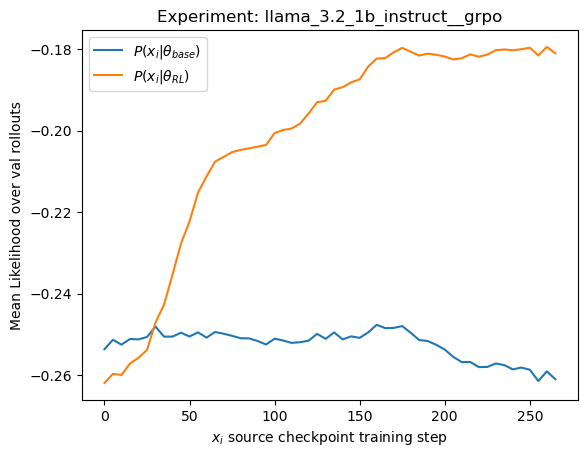

In [52]:
import matplotlib.pyplot as plt
VAL_FREQ = 5
def plot(experiment_name : str, outs : list[pd.DataFrame]) -> None:
    first, last = outs
    first_values, last_values = [], []
    first_stds, last_stds = [], []

    groups = first.groupby('data_global_step', sort=True)
    for data_step, group in groups:
        first_values.append(group['logprobs'].to_numpy().mean())
        first_stds.append(group['logprobs'].to_numpy().std())

    groups = last.groupby('data_global_step', sort=True)
    for data_step, group in groups:
        last_values.append(group['logprobs'].to_numpy().mean())
        last_stds.append(group['logprobs'].to_numpy().std())

    plt.errorbar(x=range(0, len(first_values) * VAL_FREQ, VAL_FREQ), y=first_values, label='$P(x_i|\\theta_{base})$')
    plt.errorbar(x=range(0, len(last_values) * VAL_FREQ, VAL_FREQ), y=last_values, label='$P(x_i|\\theta_{RL})$')
    plt.ylabel('Mean Likelihood over val rollouts')
    plt.xlabel('$x_i$ source checkpoint training step')
    plt.title(f'Experiment: {experiment_name}')
    plt.legend()
    plt.show()

name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__grpo/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__grpo"
plot(experiment_name, mapper[name])

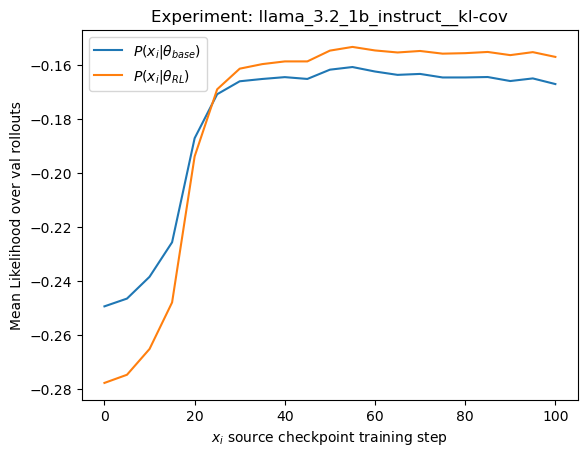

In [53]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__kl-cov/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__kl-cov"
plot(experiment_name, mapper[name])

In [54]:
outs_only_pos = {
    m : [df[df['score'] == 1] for df in v] for m, v in mapper.items()
}

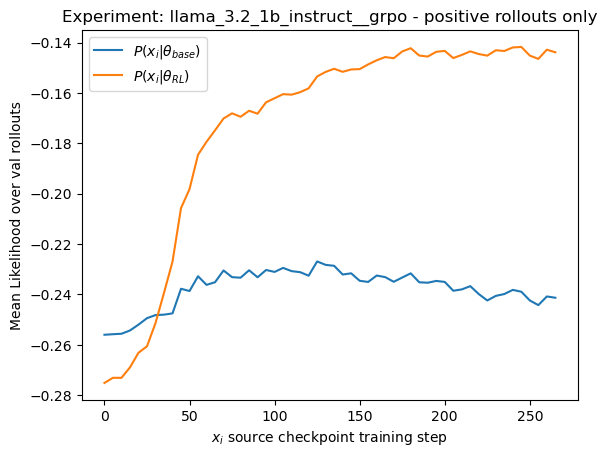

In [55]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__grpo/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__grpo - positive rollouts only"
plot(experiment_name, outs_only_pos[name])

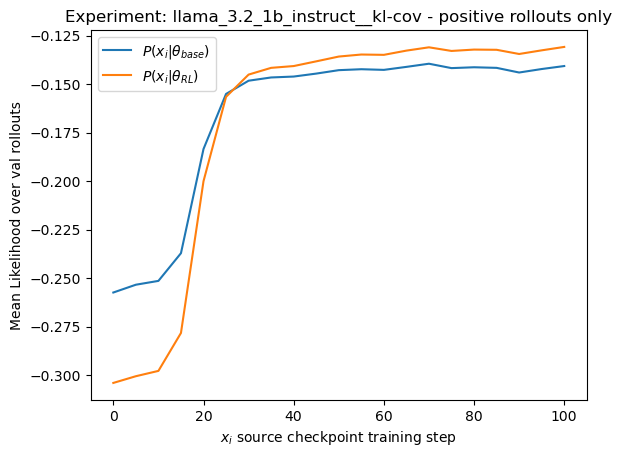

In [56]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__kl-cov/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__kl-cov - positive rollouts only"
plot(experiment_name, outs_only_pos[name])